# Notebook 10b - Training RGB Thresholds from ceilometer

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
path = '/storage/cdalden/goes/colorado/goes16/cloud_counts/'
file_template = 'goes16_cloud_frequency_colorado_{yearmonth}.nc'
datasets = {}
# Only load August 2022 data for analysis
files = ['202201', '202202', '202205', '202207', '202208', '202301', '202302', '202304', '202305']
for file in files:
    datasets[file] = xr.open_dataset(
        path + file_template.format(yearmonth=file),
        chunks={'t': 100}  # Add chunking for lazy loading
    )
    print('opened {i}'.format(i=file))

if len(files) > 1:
    cloud_ds = xr.concat([datasets[file] for file in files], dim='t', combine_attrs='override')
else:
    cloud_ds = datasets[files[0]].copy()  # Use .copy() to avoid reference issues
    
cloud_ds = cloud_ds.rename({'t': 'time'})

# Cleanup: close individual datasets to free memory
for ds in datasets.values():
    ds.close()
del datasets


cloud_ds = cloud_ds.sel(latitude=38.958, longitude=-106.989, method='nearest')
cloud_ds

FileNotFoundError: [Errno 2] No such file or directory: '/storage/cdalden/goes/colorado/goes16/cloud_counts/goes16_cloud_frequency_colorado_202201.nc'

In [ ]:
start_time = pd.to_datetime('2022-01-01')
end_time = pd.to_datetime('2023-05-31')

In [ ]:

# Select time range and filter after 14Z
cloud_ds = cloud_ds.sel(
    time=cloud_ds['time'].where(
        ((cloud_ds['time'] > start_time) &
        (cloud_ds['time'] < end_time) &
        (cloud_ds['time'].dt.hour >= 14))
    ).dropna('time')
)


In [ ]:
met_ds = xr.open_dataset('./met_30min.nc', engine='h5netcdf')
met_ds



<xarray.Dataset> Size: 3MB
Dimensions:                    (time: 31200)
Coordinates:
  * time                       (time) datetime64[ns] 250kB 2021-08-31T18:00:0...
Data variables: (12/20)
    org_precip_accum           (time) float32 125kB ...
    pwd_cumul_rain             (time) float32 125kB ...
    pwd_cumul_snow             (time) float32 125kB ...
    tbrg_precip_total          (time) float32 125kB ...
    tbrg_precip_total_corr     (time) float32 125kB ...
    atmos_pressure             (time) float32 125kB ...
    ...                         ...
    wdir_vec_mean              (time) float64 250kB ...
    pwd_err_code               (time) float64 250kB ...
    pwd_mean_vis_1min          (time) float64 250kB ...
    lat                        (time) float32 125kB ...
    lon                        (time) float32 125kB ...
    alt                        (time) float32 125kB ...
Attributes:
    units:      mm
    long_name:  Original Precipitation Accumulation

In [ ]:
path = '/glade/u/home/cdalden/scratch/surface_obs/colorado/'
file = 'sail_guc_ceilometer_2021_2023.nc'
ceil_ds = xr.open_dataset(path + file)
# Select time range and filter between 8am local and 6pm local (MDT) in one step
ceil_ds = ceil_ds.sel(
    time=ceil_ds['time'].where(
        ((ceil_ds['time'] > start_time) &
        (ceil_ds['time'] < end_time) &
        (ceil_ds['time'].dt.hour >= 14))
    ).dropna('time')
)
ceil_binary = (~ceil_ds['first_cbh'].isnull()).astype(int)

# Close original dataset - we only need the derived ceil_binary
ceil_ds.close()
del ceil_ds


In [ ]:
ceil_binary

<xarray.DataArray 'first_cbh' (time: 346440)> Size: 3MB
dask.array<astype, shape=(346440,), dtype=int64, chunksize=(499,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 3MB 2022-01-01T14:00:03 ... 2022-08-31T23:...
Attributes:
    long_name:            Lowest cloud base height detected
    units:                m
    valid_min:            0.0
    valid_max:            7700.0
    ancillary_variables:  qc_first_cbh detection_status
    comment:              If detection_status is 1, 2 or 3, a lowest cloud ba...

In [ ]:
# 1) Remove duplicate times if present
_, uniq_idx = np.unique(ceil_binary['time'], return_index=True)
ceil_binary = ceil_binary.isel(time=np.sort(uniq_idx))

# 2) Build offset 5-min target times (offset = 2.5 minutes = 150 seconds)
t0 = pd.to_datetime(ceil_binary['time'].values.min())
t1 = pd.to_datetime(ceil_binary['time'].values.max())

# Start at first 5-min multiple after t0, then add 2.5 min offset
# choose an anchored start: round up to nearest 5min boundary then add offset
start_5min = (t0.ceil('5min') + pd.Timedelta(seconds=150))
target_times = pd.date_range(start=start_5min, end=t1, freq='5min')

# 3) Pick the nearest original sample to each target time (tolerance = 2.5 min)
tol = pd.Timedelta(seconds=150)

# Use a loop-based approach to robustly select nearest times
indices = []
for t in target_times:
    # Find nearest time in ceil_binary
    time_diff = np.abs(ceil_binary['time'].values.astype('datetime64[ns]') - np.datetime64(t, 'ns'))
    idx = np.argmin(time_diff)
    # Only include if within tolerance
    if time_diff[idx] <= tol.value:
        indices.append(idx)

if indices:
    ceil_binary_5min_offset = ceil_binary.isel(time=indices)
else:
    # Fallback: create empty DataArray with target times
    ceil_binary_5min_offset = xr.DataArray(
        np.zeros(len(target_times)), 
        dims='time', 
        coords={'time': ('time', target_times)}
    )

# 4) Quick checks
print("target times (first 6):", target_times[:6])
print("Result count:", ceil_binary_5min_offset.sizes['time'])
print("Sum (number of 1s):", int(ceil_binary_5min_offset.compute().sum().item()))

# Replace original variable if desired
ceil_binary = ceil_binary_5min_offset

target times (first 6): DatetimeIndex(['2022-01-01 14:07:30', '2022-01-01 14:12:30',
               '2022-01-01 14:17:30', '2022-01-01 14:22:30',
               '2022-01-01 14:27:30', '2022-01-01 14:32:30'],
              dtype='datetime64[ns]', freq='5min')
Result count: 18489
Sum (number of 1s): 8558


In [ ]:

# Compute cloud_ds to load into memory
cloud_ds_computed = cloud_ds.compute()

# Select the nearest ceilometer binary for each cloud_ds timestep
ceil_aligned = ceil_binary.sel(time=cloud_ds_computed['time'], method='nearest')

# Extract cloud frequency as a binary (threshold at 50% for cloud detection)
# Assuming cloud frequency values are 0-100 or 0-1
cloud_frequency = cloud_ds_computed['clouds'].squeeze()
cloud_binary = (cloud_frequency > 0.5).astype(int)

# Align both binaries to common times (use ceil_aligned index)
ceil_aligned_values = ceil_aligned.values
cloud_binary_values = cloud_binary.values

print(f"Cloud DS size: {np.round(cloud_ds_computed.nbytes/10000,1)} mb")
print(f"Ceilometer aligned: {len(ceil_aligned_values)} timesteps")
print(f"Cloud binary: {len(cloud_binary_values)} timesteps")

# Cleanup
del cloud_ds_computed

Cloud DS size: 52.0 mb
Ceilometer aligned: 32520 timesteps
Cloud binary: 32520 timesteps


In [ ]:

# Compare the two binaries with evaluation metrics
# Ceilometer is treated as ground truth, Cloud DS is the model
print("=== Cloud DS Model vs Ceilometer Truth ===\n")

# Calculate performance metrics (y_true=ceilometer, y_pred=cloud_ds)
accuracy = accuracy_score(ceil_aligned_values, cloud_binary_values)
precision = precision_score(ceil_aligned_values, cloud_binary_values, zero_division=0)
recall = recall_score(ceil_aligned_values, cloud_binary_values, zero_division=0)
f1 = f1_score(ceil_aligned_values, cloud_binary_values, zero_division=0)

# Print the metrics
print("Performance Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(ceil_aligned_values, cloud_binary_values, target_names=['No Cloud', 'Cloud']))

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(ceil_aligned_values, cloud_binary_values)
print("\nConfusion Matrix (Rows=Truth/Ceilometer, Cols=Prediction/CloudDS):")
print(f"                Cloud DS Pred")
print(f"           No Cloud  Cloud")
print(f"Ceil No Cl {cm[0,0]:6d}  {cm[0,1]:6d}")
print(f"Ceil Cloud {cm[1,0]:6d}  {cm[1,1]:6d}")

# Calculate agreement statistics
agreement = np.sum(cloud_binary_values == ceil_aligned_values) / len(ceil_aligned_values)
disagreement = 1 - agreement
print(f"\nOverall Agreement: {agreement:.4f}")
print(f"Overall Disagreement: {disagreement:.4f}")


=== Cloud DS Model vs Ceilometer Truth ===

Performance Metrics:
Accuracy:  0.7023
Precision: 0.3426
Recall:    0.6684
F1 Score:  0.4530

Classification Report:
              precision    recall  f1-score   support

    No Cloud       0.90      0.71      0.80     26524
       Cloud       0.34      0.67      0.45      5996

    accuracy                           0.70     32520
   macro avg       0.62      0.69      0.62     32520
weighted avg       0.80      0.70      0.73     32520


Confusion Matrix (Rows=Truth/Ceilometer, Cols=Prediction/CloudDS):
                Cloud DS Pred
           No Cloud  Cloud
Ceil No Cl  18832    7692
Ceil Cloud   1988    4008

Overall Agreement: 0.7023
Overall Disagreement: 0.2977


In [ ]:

# Compute F1 score and confusion matrix for each month
from sklearn.metrics import confusion_matrix, f1_score
import pandas as pd

# Get month from ceil_aligned time coordinates
months = pd.to_datetime(ceil_aligned.time.values).to_period('M').unique()

print("=== Monthly Performance Metrics ===\n")

for month in months:
    # Filter data for this month
    month_mask = (pd.to_datetime(ceil_aligned.time.values).to_period('M') == month)
    
    # Get indices for this month
    month_indices = np.where(month_mask)[0]
    
    if len(month_indices) > 0:
        y_true_month = ceil_aligned_values[month_indices]
        y_pred_month = cloud_binary_values[month_indices]
        
        # Calculate F1 score
        f1_month = f1_score(y_true_month, y_pred_month, zero_division=0)
        
        # Confusion matrix
        cm_month = confusion_matrix(y_true_month, y_pred_month)
        
        print(f"Month: {month}")
        print(f"F1 Score: {f1_month:.4f}")
        print(f"Confusion Matrix:")
        print(f"           Cloud DS Pred")
        print(f"      No Cloud  Cloud")
        print(f"Ceil No Cl {cm_month[0,0]:6d}  {cm_month[0,1]:6d}")
        print(f"Ceil Cloud {cm_month[1,0]:6d}  {cm_month[1,1]:6d}")
        print()


=== Monthly Performance Metrics ===

Month: 2022-08
F1 Score: 0.2567
Confusion Matrix:
           Cloud DS Pred
      No Cloud  Cloud
Ceil No Cl  12602    6511
Ceil Cloud    855    1272

Month: 2022-01
F1 Score: 0.2407
Confusion Matrix:
           Cloud DS Pred
      No Cloud  Cloud
Ceil No Cl   2773     816
Ceil Cloud    105     146

Month: 2022-05
F1 Score: 0.8028
Confusion Matrix:
           Cloud DS Pred
      No Cloud  Cloud
Ceil No Cl   1826     265
Ceil Cloud    359    1270

Month: 2022-07
F1 Score: 0.7744
Confusion Matrix:
           Cloud DS Pred
      No Cloud  Cloud
Ceil No Cl   1631     100
Ceil Cloud    669    1320



In [ ]:
import pandas as pd

# Daytime filtering: 14Z-00Z = 8 AM - 6 PM MDT (Colorado)
# This ensures full daytime conditions for robust model training
daytime_start = 14
daytime_end = 24


In [3]:
path = '/storage/cdalden/goes/washington/goes17/rgb_composite/'
file = 'fhl_camera_goes_pixel_20220713_20220930.csv'

df = pd.read_csv(path + file)
df

FileNotFoundError: [Errno 2] No such file or directory: '/storage/cdalden/goes/washington/goes17/rgb_composite/fhl_camera_goes_pixel_20220713_20220930.csv'

In [ ]:
# Load and concatenate all RGB CSV data from east_river_cloud_binary directory
import glob

path = '/glade/u/home/cdalden/scratch/colorado/goes16/east_river_cloud_binary/'
csv_files = sorted(glob.glob(path + '*.csv'))

print(f"Found {len(csv_files)} CSV files")

# Load and concatenate all files
dfs = []
for csv_file in csv_files:
    try:
        df = pd.read_csv(csv_file, index_col=0)  # Skip the first unnamed index column
        dfs.append(df)
    except Exception as e:
        print(f"Error loading {csv_file}: {e}")

if dfs:
    rgb_df = pd.concat(dfs, ignore_index=True)
    print(f"\nLoaded RGB data with {len(rgb_df)} total samples")
    print(f"Columns: {rgb_df.columns.tolist()}")
    
    # Convert time to datetime
    rgb_df['time'] = pd.to_datetime(rgb_df['time'])
    print(f"Date range: {rgb_df['time'].min()} to {rgb_df['time'].max()}")
    
    print(f"\nRGB channels:")
    print(f"  Red:   min={rgb_df['red'].min():.4f}, max={rgb_df['red'].max():.4f}")
    print(f"  Green: min={rgb_df['green'].min():.4f}, max={rgb_df['green'].max():.4f}")
    print(f"  Blue:  min={rgb_df['blue'].min():.4f}, max={rgb_df['blue'].max():.4f}")
    
    print(f"\nCloud fractions in data:")
    print(f"  cloud_binary: {rgb_df['cloud_binary'].mean():.2%}")
    print(f"  rgb_cloud_binary: {rgb_df['rgb_cloud_binary'].mean():.2%}")
    
    print("\nFirst few rows:")
    print(rgb_df.head())
else:
    print("No CSV files loaded")
    rgb_df = None


Found 117 CSV files

Loaded RGB data with 7644 total samples
Columns: ['time', 'red', 'green', 'blue', 'cloud_binary', 'rgb_cloud_binary', 'goes_acm_cloud']
Date range: 2022-05-01 16:02:30 to 2023-05-22 23:57:30

RGB channels:
  Red:   min=0.0000, max=1.0000
  Green: min=0.0084, max=0.9940
  Blue:  min=0.0000, max=0.8022

Cloud fractions in data:
  cloud_binary: 63.13%
  rgb_cloud_binary: 61.56%

First few rows:
                 time       red     green      blue cloud_binary  \
0 2022-05-01 16:02:30  0.500734   0.43493   0.27542          1.0   
1 2022-05-01 16:07:30  0.538198  0.442787  0.271398          1.0   
2 2022-05-01 16:12:30   0.53416   0.42978  0.259172          1.0   
3 2022-05-01 16:17:30  0.493355  0.417937  0.239789          1.0   
4 2022-05-01 16:22:30  0.441992  0.411253  0.230042          1.0   

  rgb_cloud_binary goes_acm_cloud  
0                1              1  
1                1              1  
2                1              1  
3                1             

## Merge RGB Data with Ceilometer Observations

Align RGB pixel data with ceilometer binary cloud observations and prepare for decision tree training


In [ ]:
# Fresh ceilometer load with daytime filtering
path = '/glade/u/home/cdalden/scratch/surface_obs/colorado/'
file = 'sail_guc_ceilometer_2021_2023.nc'
ceil_raw = xr.open_dataset(path + file)

# Filter for daytime hours (14Z-24Z = 8am-6pm MDT)
daytime_mask = (ceil_raw['time'].dt.hour >= daytime_start) & (ceil_raw['time'].dt.hour < daytime_end)
time_range_mask = (ceil_raw['time'] > start_time) & (ceil_raw['time'] < end_time)
combined_mask = daytime_mask & time_range_mask

# Apply filter and create binary cloud indicator
ceil_filtered = ceil_raw.sel(time=ceil_raw['time'][combined_mask])
ceil_binary = (~ceil_filtered['first_cbh'].isnull()).astype(int)

print(f"Ceilometer data loaded: {len(ceil_binary)} daytime observations")
print(f"Date range: {ceil_binary['time'].min().values} to {ceil_binary['time'].max().values}")
print(f"Cloud frequency: {ceil_binary.mean().values:.2%}")

ceil_raw.close()
del ceil_raw


Ceilometer data loaded: 346440 daytime observations
Date range: 2022-01-01T14:00:03.000000000 to 2022-08-31T23:59:48.000000000
Cloud frequency: 46.15%


In [ ]:
# Merge RGB data with ceilometer observations
if rgb_df is not None:
    # Filter RGB data to same daytime hours
    rgb_df_filtered = rgb_df[
        (rgb_df['time'].dt.hour >= daytime_start) & 
        (rgb_df['time'].dt.hour < daytime_end)
    ].copy()
    
    print(f"RGB samples (daytime filtered): {len(rgb_df_filtered)}")
    print(f"RGB date range: {rgb_df_filtered['time'].min()} to {rgb_df_filtered['time'].max()}")
    
    # Convert ceilometer to dataframe for easier merging
    ceil_df = ceil_binary.to_dataframe().reset_index()
    ceil_df['time'] = pd.to_datetime(ceil_df['time'])
    ceil_df = ceil_df.drop(columns=['spatial_ref'], errors='ignore')
    ceil_df = ceil_df.rename(columns={ceil_df.columns[1]: 'ceil_cloud'})  # Rename the cloud indicator column
    
    print(f"Ceilometer samples: {len(ceil_df)}")
    
    # Convert both times to same resolution (nanoseconds)
    rgb_df_filtered['time'] = rgb_df_filtered['time'].astype('datetime64[ns]')
    ceil_df['time'] = ceil_df['time'].astype('datetime64[ns]')
    
    # Sort both by time
    rgb_df_filtered = rgb_df_filtered.sort_values('time').reset_index(drop=True)
    ceil_df = ceil_df.sort_values('time').reset_index(drop=True)
    
    # Merge on nearest time (within 10 minutes)
    merged_data = pd.merge_asof(
        rgb_df_filtered[['time', 'red', 'green', 'blue']],
        ceil_df[['time', 'ceil_cloud']],
        on='time',
        direction='nearest',
        tolerance=pd.Timedelta('10min')
    )
    
    # Drop NaN values
    merged_data = merged_data.dropna()
    
    print(f"\nMerged RGB-ceilometer samples: {len(merged_data)}")
    print(f"Cloudy samples: {(merged_data['ceil_cloud'] == 1).sum()}")
    print(f"Clear samples: {(merged_data['ceil_cloud'] == 0).sum()}")
    print(f"Cloud fraction: {merged_data['ceil_cloud'].mean():.2%}")
    print("\nFirst few rows:")
    print(merged_data.head(10))
else:
    print("RGB data not loaded. Skipping merge.")
    merged_data = None


RGB samples (daytime filtered): 7644
RGB date range: 2022-05-01 16:02:30 to 2023-05-22 23:57:30
Ceilometer samples: 346440

Merged RGB-ceilometer samples: 1992
Cloudy samples: 1415
Clear samples: 577
Cloud fraction: 71.03%

First few rows:
                 time       red     green      blue  ceil_cloud
0 2022-05-01 16:02:30  0.500734   0.43493   0.27542         1.0
1 2022-05-01 16:07:30  0.538198  0.442787  0.271398         1.0
2 2022-05-01 16:12:30   0.53416   0.42978  0.259172         1.0
3 2022-05-01 16:17:30  0.493355  0.417937  0.239789         1.0
4 2022-05-01 16:22:30  0.441992  0.411253  0.230042         1.0
5 2022-05-01 16:27:30  0.352254  0.415315  0.183712         1.0
6 2022-05-01 17:42:30  0.434509  0.583567  0.297125         1.0
7 2022-05-01 17:47:30  0.558966  0.666393  0.366745         0.0
8 2022-05-01 17:52:30  0.611047  0.734213  0.391886         1.0
9 2022-05-01 17:57:30  0.624353   0.77523  0.385068         1.0


## Train Decision Tree Classifier

Train an RGB decision tree using ceilometer cloud observations as ground truth


In [ ]:
if merged_data is not None and len(merged_data) > 50:
    # Prepare features and target
    X = merged_data[['red', 'green', 'blue']].values
    y = merged_data['ceil_cloud'].values.astype(float)
    
    print(f"Training samples: {len(X)}")
    print(f"Features shape: {X.shape}")
    print(f"Target cloud fraction: {y.mean():.2%}")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    print(f"\nTrain set: {len(X_train)} samples, cloud frac: {y_train.mean():.2%}")
    print(f"Test set: {len(X_test)} samples, cloud frac: {y_test.mean():.2%}")
    
    # Train decision tree
    dt_model = DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    )
    
    dt_model.fit(X_train, y_train)
    
    # Evaluate
    y_pred_train = dt_model.predict(X_train)
    y_pred_test = dt_model.predict(X_test)
    
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    
    print("\n" + "="*60)
    print("DECISION TREE PERFORMANCE (Ceilometer Ground Truth)")
    print("="*60)
    print(f"\nTraining Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy:  {test_acc:.4f}")
    
    print(f"\nTest Set Metrics:")
    print(f"  Precision: {precision_score(y_test, y_pred_test, zero_division=0):.4f}")
    print(f"  Recall:    {recall_score(y_test, y_pred_test, zero_division=0):.4f}")
    print(f"  F1 Score:  {f1_score(y_test, y_pred_test, zero_division=0):.4f}")
    
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred_test, target_names=['Clear', 'Cloudy']))
    
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test, y_pred_test)
    print(f"\nConfusion Matrix (Test Set):")
    print(f"           Predicted")
    print(f"      Clear  Cloudy")
    print(f"True Clear {cm[0,0]:5d}  {cm[0,1]:5d}")
    print(f"     Cloudy {cm[1,0]:5d}  {cm[1,1]:5d}")
    
    # Feature importance
    print(f"\nFeature Importance:")
    for name, importance in zip(['Red', 'Green', 'Blue'], dt_model.feature_importances_):
        print(f"  {name}: {importance:.4f}")

else:
    print("Cannot train model - insufficient merged data")


Training samples: 1992
Features shape: (1992, 3)
Target cloud fraction: 71.03%

Train set: 1394 samples, cloud frac: 71.02%
Test set: 598 samples, cloud frac: 71.07%

DECISION TREE PERFORMANCE (Ceilometer Ground Truth)

Training Accuracy: 0.9562
Testing Accuracy:  0.9532

Test Set Metrics:
  Precision: 0.9522
  Recall:    0.9835
  F1 Score:  0.9676

Classification Report:
              precision    recall  f1-score   support

       Clear       0.96      0.88      0.92       173
      Cloudy       0.95      0.98      0.97       425

    accuracy                           0.95       598
   macro avg       0.95      0.93      0.94       598
weighted avg       0.95      0.95      0.95       598


Confusion Matrix (Test Set):
           Predicted
      Clear  Cloudy
True Clear   152     21
     Cloudy     7    418

Feature Importance:
  Red: 0.9072
  Green: 0.0252
  Blue: 0.0677


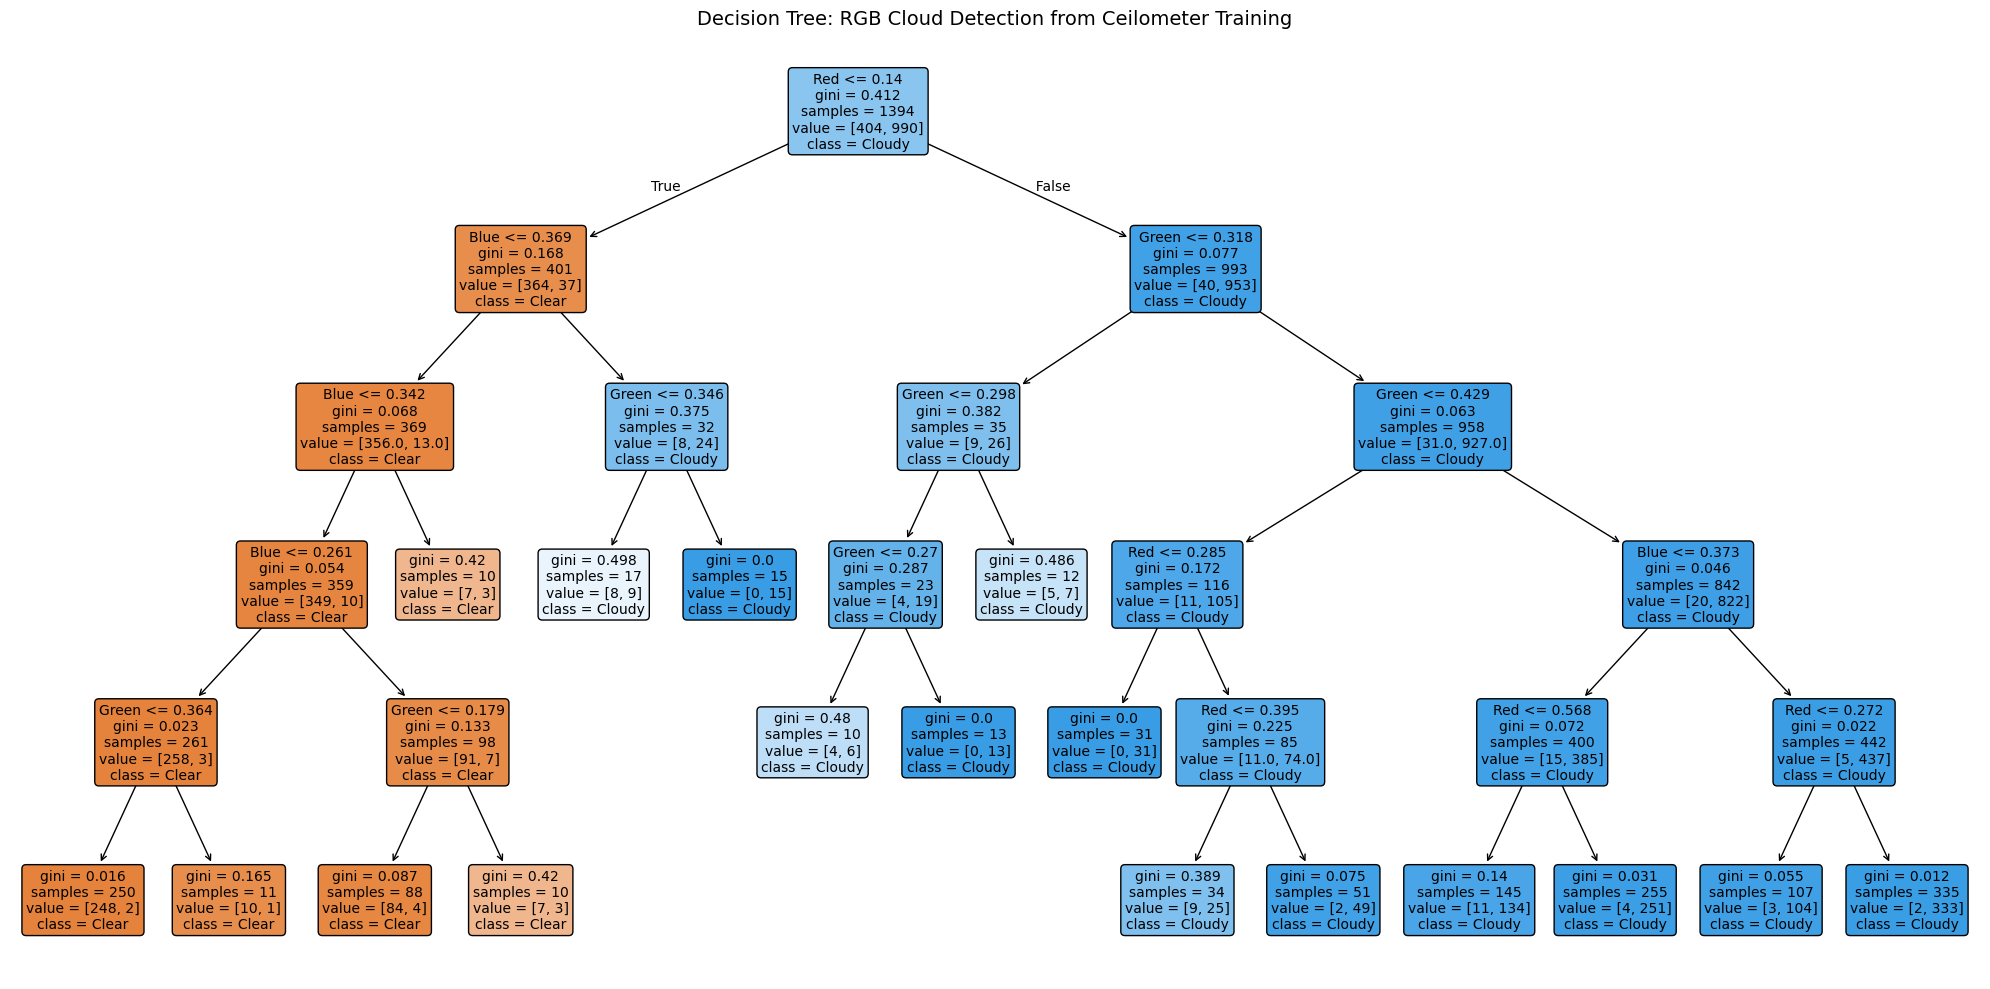

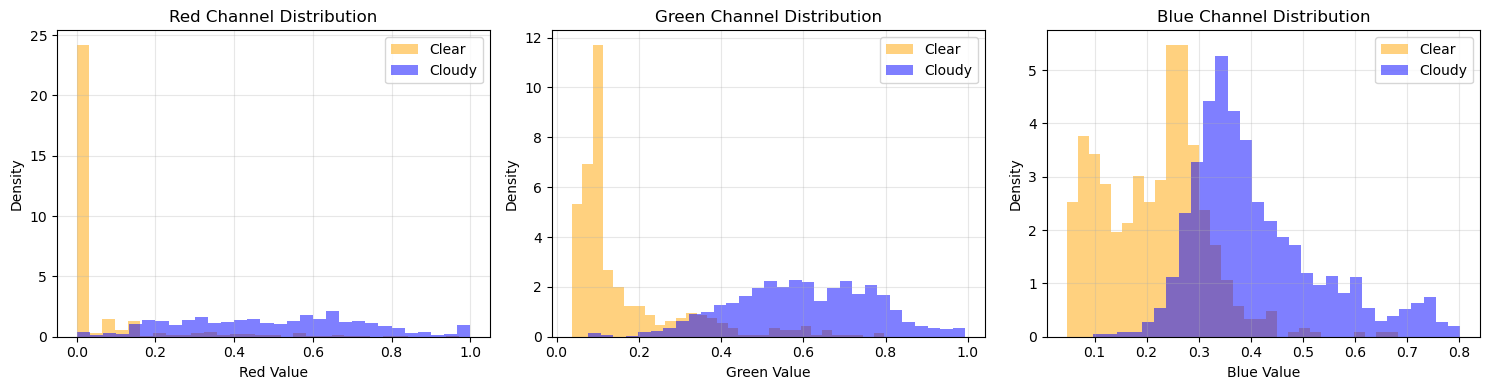

In [ ]:
# Visualize the decision tree
if merged_data is not None and len(merged_data) > 50:
    fig, ax = plt.subplots(figsize=(20, 10))
    plot_tree(dt_model, 
              feature_names=['Red', 'Green', 'Blue'],
              class_names=['Clear', 'Cloudy'],
              filled=True,
              rounded=True,
              ax=ax,
              fontsize=10)
    plt.title('Decision Tree: RGB Cloud Detection from Ceilometer Training', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Plot RGB distributions by cloud class
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    colors = ['red', 'green', 'blue']
    
    for i, (ax, color, name) in enumerate(zip(axes, colors, ['Red', 'Green', 'Blue'])):
        clear_vals = merged_data[merged_data['ceil_cloud'] == 0][color]
        cloudy_vals = merged_data[merged_data['ceil_cloud'] == 1][color]
        
        ax.hist(clear_vals, bins=30, alpha=0.5, label='Clear', color='orange', density=True)
        ax.hist(cloudy_vals, bins=30, alpha=0.5, label='Cloudy', color='blue', density=True)
        ax.set_xlabel(f'{name} Value')
        ax.set_ylabel('Density')
        ax.set_title(f'{name} Channel Distribution')
        ax.legend()
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


## Compare Ceilometer to TSI Observations

Evaluate ceilometer cloud detection against TSI observations (ground truth from RGB analysis)


In [ ]:
# Prepare RGB cloud_binary as ground truth (already in rgb_df)
# cloud_binary is the TSI-derived truth from the RGB CSV files

print("Ground Truth Data (from RGB CSVs):")
print(f"Total RGB samples: {len(rgb_df)}")
print(f"Cloud binary column: {'cloud_binary' in rgb_df.columns}")

if 'cloud_binary' in rgb_df.columns:
    print(f"Cloud fraction (RGB cloud_binary): {rgb_df['cloud_binary'].mean():.2%}")
    print(f"Date range: {rgb_df['time'].min()} to {rgb_df['time'].max()}")
    print("\nFirst few rows with ground truth:")
    print(rgb_df[['time', 'cloud_binary']].head(10))
else:
    print("ERROR: cloud_binary not found in RGB data!")


Ground Truth Data (from RGB CSVs):
Total RGB samples: 7644
Cloud binary column: True
Cloud fraction (RGB cloud_binary): 63.13%
Date range: 2022-05-01 16:02:30 to 2023-05-22 23:57:30

First few rows with ground truth:
                 time cloud_binary
0 2022-05-01 16:02:30          1.0
1 2022-05-01 16:07:30          1.0
2 2022-05-01 16:12:30          1.0
3 2022-05-01 16:17:30          1.0
4 2022-05-01 16:22:30          1.0
5 2022-05-01 16:27:30          1.0
6 2022-05-01 17:42:30          1.0
7 2022-05-01 17:47:30          1.0
8 2022-05-01 17:52:30          1.0
9 2022-05-01 17:57:30          1.0


In [ ]:
# Merge ceilometer and RGB cloud_binary (ground truth)
if rgb_df is not None and 'cloud_binary' in rgb_df.columns:
    # Filter RGB to daytime hours
    rgb_truth_filtered = rgb_df[
        (rgb_df['time'].dt.hour >= daytime_start) & 
        (rgb_df['time'].dt.hour < daytime_end)
    ][['time', 'cloud_binary']].copy()
    
    print(f"RGB ground truth samples (daytime): {len(rgb_truth_filtered)}")
    print(f"RGB date range: {rgb_truth_filtered['time'].min()} to {rgb_truth_filtered['time'].max()}")
    print(f"Cloud fraction: {rgb_truth_filtered['cloud_binary'].mean():.2%}")
    
    # Convert ceilometer to dataframe
    ceil_df_truth = ceil_binary.to_dataframe().reset_index()
    ceil_df_truth['time'] = pd.to_datetime(ceil_df_truth['time'])
    ceil_df_truth = ceil_df_truth.drop(columns=['spatial_ref'], errors='ignore')
    ceil_df_truth = ceil_df_truth.rename(columns={ceil_df_truth.columns[1]: 'ceil_cloud'})
    
    print(f"Ceilometer samples: {len(ceil_df_truth)}")
    
    # Standardize datetime types
    rgb_truth_filtered['time'] = rgb_truth_filtered['time'].astype('datetime64[ns]')
    ceil_df_truth['time'] = ceil_df_truth['time'].astype('datetime64[ns]')
    
    # Sort and merge
    rgb_truth_filtered = rgb_truth_filtered.sort_values('time').reset_index(drop=True)
    ceil_df_truth = ceil_df_truth.sort_values('time').reset_index(drop=True)
    
    # Merge on nearest time (within 10 minutes)
    ceil_vs_rgb_truth = pd.merge_asof(
        ceil_df_truth[['time', 'ceil_cloud']],
        rgb_truth_filtered[['time', 'cloud_binary']],
        on='time',
        direction='nearest',
        tolerance=pd.Timedelta('10min')
    )
    
    ceil_vs_rgb_truth = ceil_vs_rgb_truth.dropna()
    
    print(f"\nMerged ceilometer-RGB ground truth samples: {len(ceil_vs_rgb_truth)}")
    print(f"Ceilometer cloud fraction: {ceil_vs_rgb_truth['ceil_cloud'].mean():.2%}")
    print(f"RGB ground truth cloud fraction: {ceil_vs_rgb_truth['cloud_binary'].mean():.2%}")
    print("\nFirst few rows:")
    print(ceil_vs_rgb_truth.head(10))
else:
    print("RGB ground truth not available")
    ceil_vs_rgb_truth = None


TSI samples (daytime): 706984
TSI date range: 2021-10-01 14:00:00 to 2023-05-31 23:59:30
TSI cloud fraction: 38.66%
Ceilometer samples: 346440

Merged ceilometer-TSI samples: 343780
Ceilometer cloud fraction: 46.15%
TSI cloud fraction: 38.41%

First few rows:
                  time  ceil_cloud  cloud_binary
83 2022-01-01 14:22:11           1           0.0
84 2022-01-01 14:22:27           1           0.0
85 2022-01-01 14:22:43           1           0.0
86 2022-01-01 14:22:59           1           0.0
87 2022-01-01 14:23:15           1           0.0
88 2022-01-01 14:23:31           1           0.0
89 2022-01-01 14:23:47           1           0.0
90 2022-01-01 14:24:03           1           0.0
91 2022-01-01 14:24:19           1           0.0
92 2022-01-01 14:24:35           1           0.0


In [ ]:
# Evaluate ceilometer against RGB ground truth
if ceil_vs_rgb_truth is not None and len(ceil_vs_rgb_truth) > 0:
    y_true_rgb = ceil_vs_rgb_truth['cloud_binary'].values.astype(float)
    y_pred_ceil = ceil_vs_rgb_truth['ceil_cloud'].values.astype(float)
    
    # Calculate metrics
    accuracy_ceil_vs_rgb = accuracy_score(y_true_rgb, y_pred_ceil)
    precision_ceil_vs_rgb = precision_score(y_true_rgb, y_pred_ceil, zero_division=0)
    recall_ceil_vs_rgb = recall_score(y_true_rgb, y_pred_ceil, zero_division=0)
    f1_ceil_vs_rgb = f1_score(y_true_rgb, y_pred_ceil, zero_division=0)
    
    print("="*70)
    print("CEILOMETER vs RGB GROUND TRUTH COMPARISON")
    print("="*70)
    
    print(f"\nPerformance Metrics:")
    print(f"  Accuracy:  {accuracy_ceil_vs_rgb:.4f}")
    print(f"  Precision: {precision_ceil_vs_rgb:.4f}")
    print(f"  Recall:    {recall_ceil_vs_rgb:.4f}")
    print(f"  F1 Score:  {f1_ceil_vs_rgb:.4f}")
    
    print(f"\nClassification Report:")
    print(classification_report(y_true_rgb, y_pred_ceil, target_names=['Clear', 'Cloudy']))
    
    cm_ceil_rgb = confusion_matrix(y_true_rgb, y_pred_ceil)
    print(f"Confusion Matrix (RGB=Ground Truth, Ceilometer=Prediction):")
    print(f"           Predicted")
    print(f"      Clear  Cloudy")
    print(f"RGB Clear {cm_ceil_rgb[0,0]:5d}  {cm_ceil_rgb[0,1]:5d}")
    print(f"    Cloudy {cm_ceil_rgb[1,0]:5d}  {cm_ceil_rgb[1,1]:5d}")
    
    # Summary statistics
    agreement = np.sum(y_pred_ceil == y_true_rgb) / len(y_true_rgb)
    disagreement = 1 - agreement
    print(f"\nOverall Agreement: {agreement:.4f}")
    print(f"Overall Disagreement: {disagreement:.4f}")
    
    # False positives and false negatives
    false_positives = cm_ceil_rgb[0, 1]
    false_negatives = cm_ceil_rgb[1, 0]
    print(f"\nError Analysis:")
    print(f"  False Positives (clear→cloudy): {false_positives}")
    print(f"  False Negatives (cloudy→clear): {false_negatives}")
    print(f"  Total errors: {false_positives + false_negatives}")

else:
    print("No merged data available for comparison")


CEILOMETER vs TSI COMPARISON (TSI = Ground Truth)

Performance Metrics:
  Accuracy:  0.8489
  Precision: 0.7525
  Recall:    0.9041
  F1 Score:  0.8214

Classification Report:
              precision    recall  f1-score   support

       Clear       0.93      0.81      0.87    211725
      Cloudy       0.75      0.90      0.82    132055

    accuracy                           0.85    343780
   macro avg       0.84      0.86      0.85    343780
weighted avg       0.86      0.85      0.85    343780

Confusion Matrix (TSI=Truth, Ceilometer=Prediction):
           Predicted
      Clear  Cloudy
TSI Clear 172456  39269
    Cloudy 12660  119395

Overall Agreement: 0.8489
Overall Disagreement: 0.1511

Error Analysis:
  False Positives (clear→cloudy): 39269
  False Negatives (cloudy→clear): 12660
  Total errors: 51929


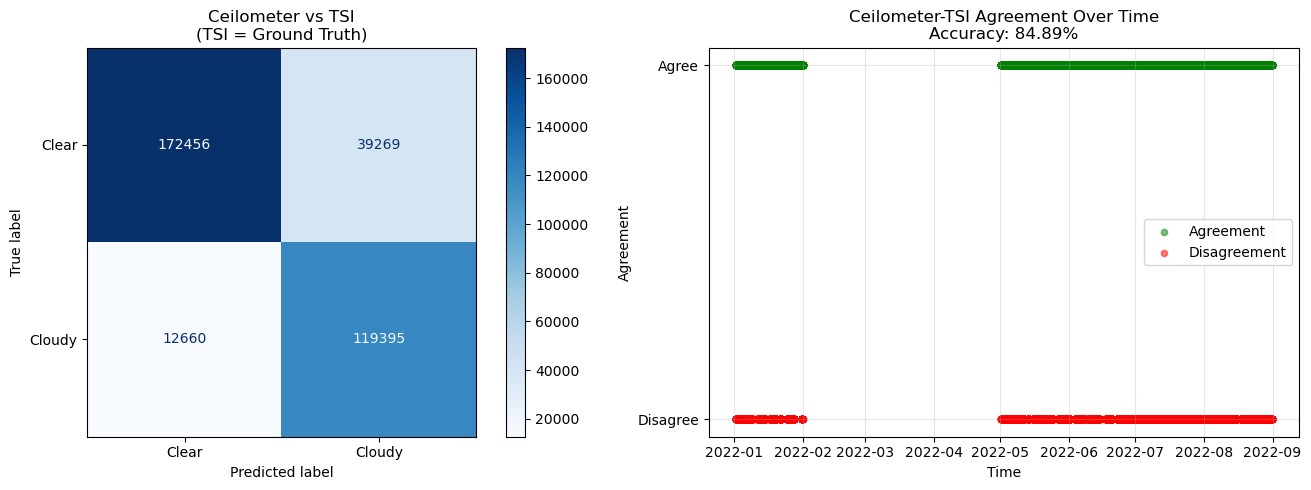

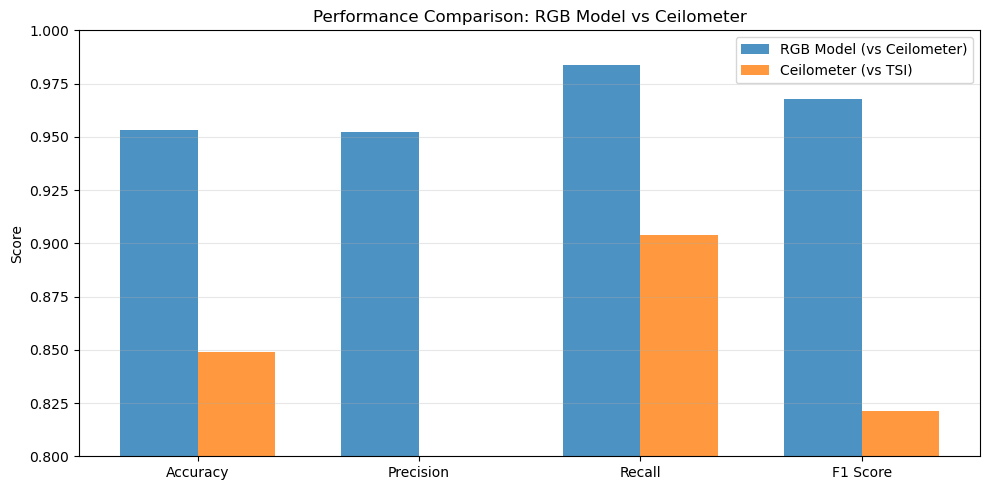

In [ ]:
# Visualize ceilometer vs RGB ground truth comparison
if ceil_vs_rgb_truth is not None and len(ceil_vs_rgb_truth) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Confusion matrix heatmap
    from sklearn.metrics import ConfusionMatrixDisplay
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_ceil_rgb, 
                                   display_labels=['Clear', 'Cloudy'])
    disp.plot(ax=axes[0], cmap='Blues', values_format='d')
    axes[0].set_title('Ceilometer vs RGB Ground Truth\n(RGB = Ground Truth)')
    
    # Time series scatter plot of agreement/disagreement
    agreed = np.array(y_pred_ceil) == np.array(y_true_rgb)
    
    times_ceil = pd.to_datetime(ceil_vs_rgb_truth['time'])
    
    axes[1].scatter(times_ceil[agreed], np.ones(agreed.sum()), 
                   alpha=0.5, s=20, label='Agreement', color='green')
    axes[1].scatter(times_ceil[~agreed], -np.ones((~agreed).sum()), 
                   alpha=0.5, s=20, label='Disagreement', color='red')
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel('Agreement')
    axes[1].set_yticks([-1, 1])
    axes[1].set_yticklabels(['Disagree', 'Agree'])
    axes[1].set_title(f'Ceilometer-RGB Agreement Over Time\nAccuracy: {accuracy_ceil_vs_rgb:.2%}')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Performance comparison bar chart
    fig, ax = plt.subplots(figsize=(10, 5))
    
    metrics_ceil_rgb = [accuracy_ceil_vs_rgb, precision_ceil_vs_rgb, 
                        recall_ceil_vs_rgb, f1_ceil_vs_rgb]
    
    # Original RGB model metrics for comparison
    metrics_rgb = [test_acc, precision_score(y_test, y_pred_test, zero_division=0), 
                   recall_score(y_test, y_pred_test, zero_division=0), 
                   f1_score(y_test, y_pred_test, zero_division=0)]
    
    x = np.arange(4)
    width = 0.35
    
    ax.bar(x - width/2, metrics_rgb, width, label='RGB Model (vs Ceilometer)', alpha=0.8)
    ax.bar(x + width/2, metrics_ceil_rgb, width, label='Ceilometer (vs RGB Ground Truth)', alpha=0.8)
    
    ax.set_ylabel('Score')
    ax.set_title('Performance Comparison: RGB Model vs Ceilometer')
    ax.set_xticks(x)
    ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1 Score'])
    ax.legend()
    ax.set_ylim([0.8, 1.0])
    ax.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()


## Model Comparison: Ceilometer-trained RGB vs TSI-trained RGB

Compare two RGB decision tree models: one trained with ceilometer observations vs the existing TSI-trained RGB model


In [ ]:
# Apply ceilometer-trained RGB model to all RGB data
# Compare predictions to TSI-trained rgb_binary column

# Filter RGB data to daytime hours
rgb_daytime = rgb_df[
    (rgb_df['time'].dt.hour >= daytime_start) & 
    (rgb_df['time'].dt.hour < daytime_end)
].copy()

print(f"RGB data (daytime): {len(rgb_daytime)} samples")

# Get RGB features
X_rgb_all = rgb_daytime[['red', 'green', 'blue']].values

# Apply ceilometer-trained model (dt_model was trained on ceilometer)
y_pred_ceil_model = dt_model.predict(X_rgb_all)

# Get TSI-trained RGB binary (rgb_cloud_binary) and TSI ground truth (cloud_binary)
y_tsi_rgb_model = rgb_daytime['rgb_cloud_binary'].values.astype(int)  # TSI-trained RGB model predictions
y_tsi_truth = rgb_daytime['cloud_binary'].values.astype(int)           # TSI ground truth

print(f"\nPredictions on all RGB data:")
print(f"  Ceilometer model cloud fraction: {y_pred_ceil_model.mean():.2%}")
print(f"  TSI-trained RGB binary: {y_tsi_rgb_model.mean():.2%}")
print(f"  TSI ground truth (cloud_binary): {y_tsi_truth.mean():.2%}")

# Compare ceilometer model to TSI ground truth
print("\n" + "="*70)
print("CEILOMETER-TRAINED RGB MODEL vs TSI GROUND TRUTH")
print("="*70)

accuracy_ceil_model = accuracy_score(y_tsi_truth, y_pred_ceil_model)
precision_ceil_model = precision_score(y_tsi_truth, y_pred_ceil_model, zero_division=0)
recall_ceil_model = recall_score(y_tsi_truth, y_pred_ceil_model, zero_division=0)
f1_ceil_model = f1_score(y_tsi_truth, y_pred_ceil_model, zero_division=0)

print(f"\nCeilometer Model Metrics:")
print(f"  Accuracy:  {accuracy_ceil_model:.4f}")
print(f"  Precision: {precision_ceil_model:.4f}")
print(f"  Recall:    {recall_ceil_model:.4f}")
print(f"  F1 Score:  {f1_ceil_model:.4f}")

cm_ceil_model = confusion_matrix(y_tsi_truth, y_pred_ceil_model)
print(f"\nConfusion Matrix (Ceilometer Model):")
print(f"           Predicted")
print(f"      Clear  Cloudy")
print(f"TSI Clear {cm_ceil_model[0,0]:5d}  {cm_ceil_model[0,1]:5d}")
print(f"    Cloudy {cm_ceil_model[1,0]:5d}  {cm_ceil_model[1,1]:5d}")

# Compare TSI-trained RGB to TSI ground truth
print("\n" + "="*70)
print("TSI-TRAINED RGB BINARY vs TSI GROUND TRUTH")
print("="*70)

accuracy_tsi_model = accuracy_score(y_tsi_truth, y_tsi_rgb_model)
precision_tsi_model = precision_score(y_tsi_truth, y_tsi_rgb_model, zero_division=0)
recall_tsi_model = recall_score(y_tsi_truth, y_tsi_rgb_model, zero_division=0)
f1_tsi_model = f1_score(y_tsi_truth, y_tsi_rgb_model, zero_division=0)

print(f"\nTSI-trained RGB Model Metrics:")
print(f"  Accuracy:  {accuracy_tsi_model:.4f}")
print(f"  Precision: {precision_tsi_model:.4f}")
print(f"  Recall:    {recall_tsi_model:.4f}")
print(f"  F1 Score:  {f1_tsi_model:.4f}")

cm_tsi_model = confusion_matrix(y_tsi_truth, y_tsi_rgb_model)
print(f"\nConfusion Matrix (TSI-trained RGB):")
print(f"           Predicted")
print(f"      Clear  Cloudy")
print(f"TSI Clear {cm_tsi_model[0,0]:5d}  {cm_tsi_model[0,1]:5d}")
print(f"    Cloudy {cm_tsi_model[1,0]:5d}  {cm_tsi_model[1,1]:5d}")

# Compare the two models to each other
print("\n" + "="*70)
print("CEILOMETER-TRAINED RGB vs TSI-TRAINED RGB (Both evaluating TSI truth)")
print("="*70)

agreement_models = np.sum(y_pred_ceil_model == y_tsi_rgb_model) / len(y_pred_ceil_model)
print(f"\nModel-to-Model Agreement: {agreement_models:.4f}")
print(f"Model Disagreement: {1-agreement_models:.4f}")

# Summary comparison table
print("\n" + "="*70)
print("SUMMARY COMPARISON TABLE (Ground Truth = TSI cloud_binary)")
print("="*70)
print(f"{'Metric':<15} {'Ceil Model':<15} {'TSI-RGB Model':<15} {'Difference':<15}")
print("-" * 60)
print(f"{'Accuracy':<15} {accuracy_ceil_model:<15.4f} {accuracy_tsi_model:<15.4f} {accuracy_ceil_model - accuracy_tsi_model:<15.4f}")
print(f"{'Precision':<15} {precision_ceil_model:<15.4f} {precision_tsi_model:<15.4f} {precision_ceil_model - precision_tsi_model:<15.4f}")
print(f"{'Recall':<15} {recall_ceil_model:<15.4f} {recall_tsi_model:<15.4f} {recall_ceil_model - recall_tsi_model:<15.4f}")
print(f"{'F1 Score':<15} {f1_ceil_model:<15.4f} {f1_tsi_model:<15.4f} {f1_ceil_model - f1_tsi_model:<15.4f}")


RGB data (daytime): 7644 samples

Predictions on all RGB data:
  Ceilometer model cloud fraction: 89.68%
  TSI-trained RGB binary: 61.56%
  TSI ground truth (cloud_binary): 63.13%

CEILOMETER-TRAINED RGB MODEL vs TSI GROUND TRUTH

Ceilometer Model Metrics:
  Accuracy:  0.7325
  Precision: 0.7028
  Recall:    0.9983
  F1 Score:  0.8249

Confusion Matrix (Ceilometer Model):
           Predicted
      Clear  Cloudy
TSI Clear   781   2037
    Cloudy     8   4818

TSI-TRAINED RGB BINARY vs TSI GROUND TRUTH

TSI-trained RGB Model Metrics:
  Accuracy:  0.9694
  Precision: 0.9879
  Recall:    0.9633
  F1 Score:  0.9755

Confusion Matrix (TSI-trained RGB):
           Predicted
      Clear  Cloudy
TSI Clear  2761     57
    Cloudy   177   4649

CEILOMETER-TRAINED RGB vs TSI-TRAINED RGB (Both evaluating TSI truth)

Model-to-Model Agreement: 0.7176
Model Disagreement: 0.2824

SUMMARY COMPARISON TABLE (Ground Truth = TSI cloud_binary)
Metric          Ceil Model      TSI-RGB Model   Difference     


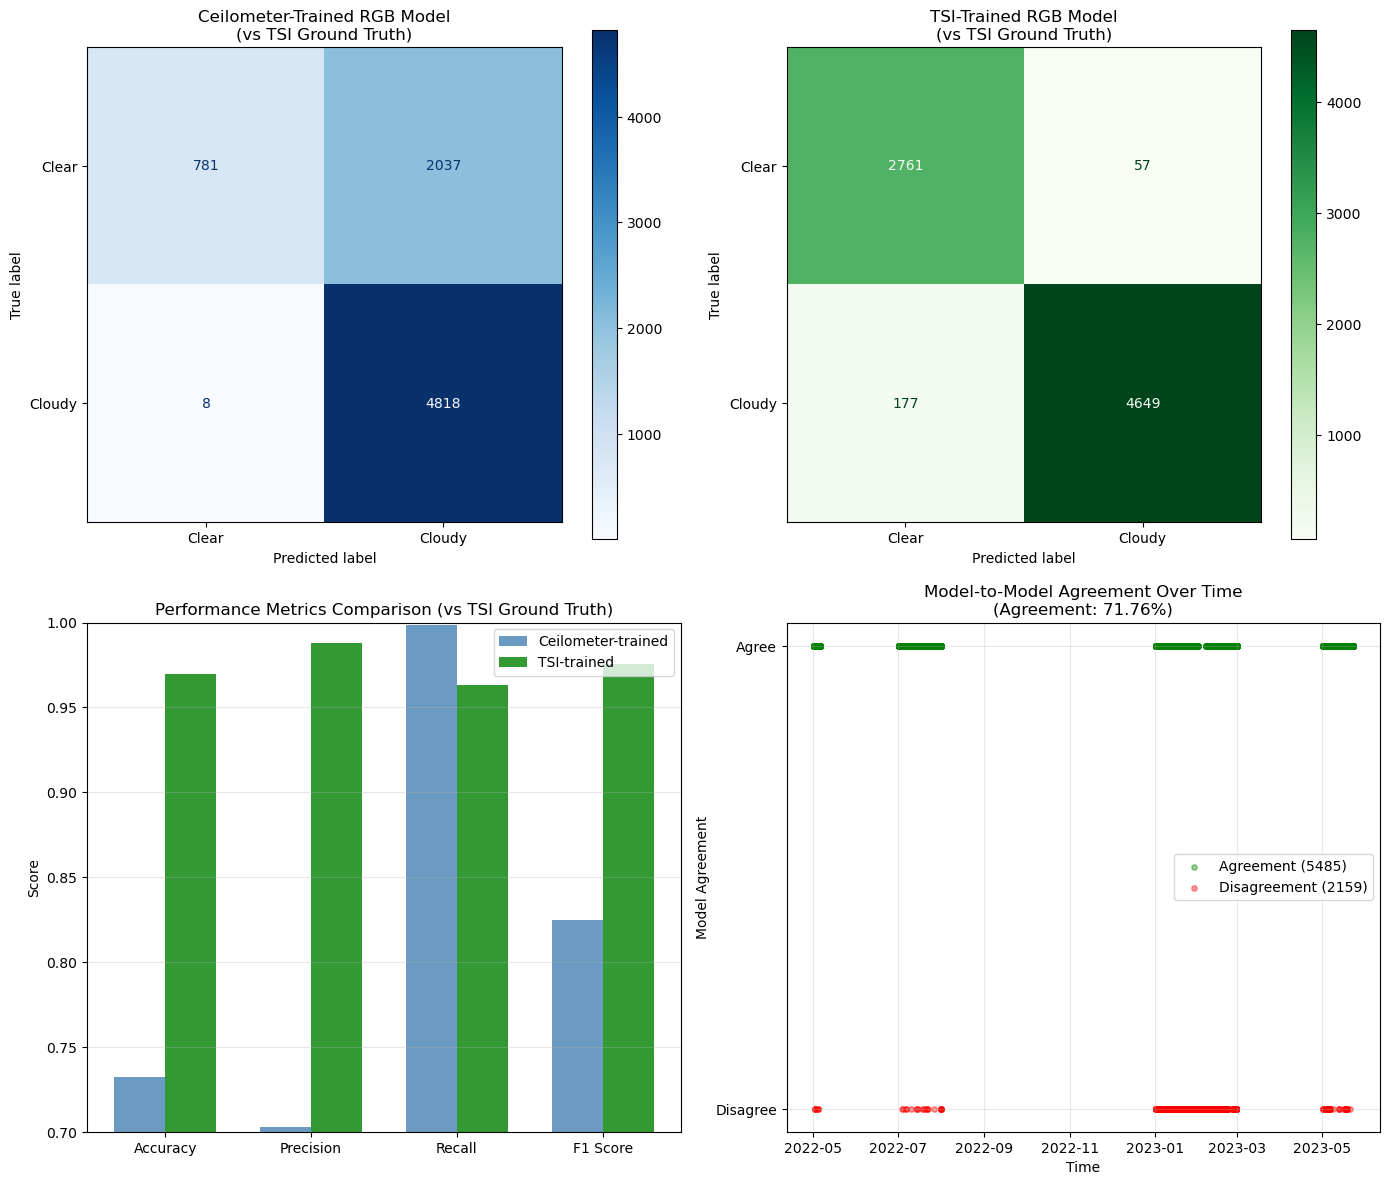

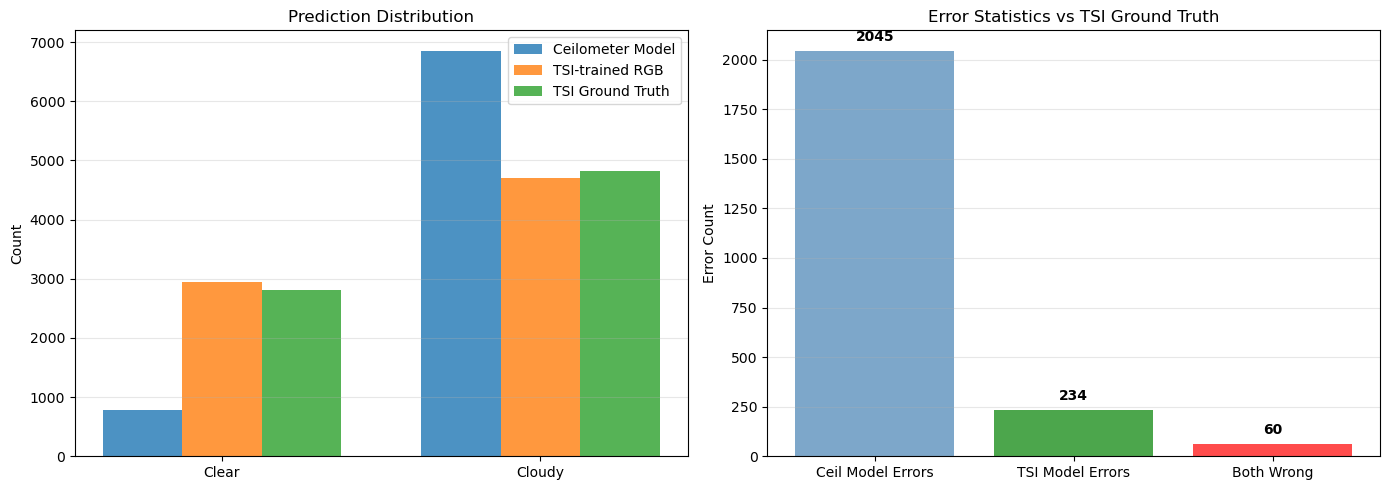

In [ ]:
# Visualization: Compare model performance
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Confusion matrices side by side
from sklearn.metrics import ConfusionMatrixDisplay

disp_ceil = ConfusionMatrixDisplay(confusion_matrix=cm_ceil_model, 
                                   display_labels=['Clear', 'Cloudy'])
disp_ceil.plot(ax=axes[0, 0], cmap='Blues', values_format='d')
axes[0, 0].set_title('Ceilometer-Trained RGB Model\n(vs TSI Ground Truth)')

disp_tsi = ConfusionMatrixDisplay(confusion_matrix=cm_tsi_model, 
                                  display_labels=['Clear', 'Cloudy'])
disp_tsi.plot(ax=axes[0, 1], cmap='Greens', values_format='d')
axes[0, 1].set_title('TSI-Trained RGB Model\n(vs TSI Ground Truth)')

# 2. Performance metrics comparison bar chart
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
ceil_metrics = [accuracy_ceil_model, precision_ceil_model, recall_ceil_model, f1_ceil_model]
tsi_metrics = [accuracy_tsi_model, precision_tsi_model, recall_tsi_model, f1_tsi_model]

x = np.arange(len(metrics_names))
width = 0.35

axes[1, 0].bar(x - width/2, ceil_metrics, width, label='Ceilometer-trained', alpha=0.8, color='steelblue')
axes[1, 0].bar(x + width/2, tsi_metrics, width, label='TSI-trained', alpha=0.8, color='green')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Performance Metrics Comparison (vs TSI Ground Truth)')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metrics_names)
axes[1, 0].legend()
axes[1, 0].set_ylim([0.7, 1.0])
axes[1, 0].grid(alpha=0.3, axis='y')

# 3. Model agreement scatter plot
times_rgb = pd.to_datetime(rgb_daytime['time'])
model_agree = y_pred_ceil_model == y_tsi_rgb_model

axes[1, 1].scatter(times_rgb[model_agree], np.ones(model_agree.sum()), 
                   alpha=0.4, s=15, label=f'Agreement ({model_agree.sum()})', color='green')
axes[1, 1].scatter(times_rgb[~model_agree], -np.ones((~model_agree).sum()), 
                   alpha=0.4, s=15, label=f'Disagreement ({(~model_agree).sum()})', color='red')
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('Model Agreement')
axes[1, 1].set_yticks([-1, 1])
axes[1, 1].set_yticklabels(['Disagree', 'Agree'])
axes[1, 1].set_title(f'Model-to-Model Agreement Over Time\n(Agreement: {agreement_models:.2%})')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Additional comparison heatmap - showing prediction distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prediction class distribution
classes = ['Clear', 'Cloudy']
ceil_dist = [np.sum(y_pred_ceil_model == 0), np.sum(y_pred_ceil_model == 1)]
tsi_dist = [np.sum(y_tsi_rgb_model == 0), np.sum(y_tsi_rgb_model == 1)]
truth_dist = [np.sum(y_tsi_truth == 0), np.sum(y_tsi_truth == 1)]

x = np.arange(len(classes))
width = 0.25

axes[0].bar(x - width, ceil_dist, width, label='Ceilometer Model', alpha=0.8)
axes[0].bar(x, tsi_dist, width, label='TSI-trained RGB', alpha=0.8)
axes[0].bar(x + width, truth_dist, width, label='TSI Ground Truth', alpha=0.8)
axes[0].set_ylabel('Count')
axes[0].set_title('Prediction Distribution')
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# Error statistics
ceil_errors = np.sum(y_pred_ceil_model != y_tsi_truth)
tsi_errors = np.sum(y_tsi_rgb_model != y_tsi_truth)
mutual_errors = np.sum((y_pred_ceil_model != y_tsi_truth) & (y_tsi_rgb_model != y_tsi_truth))

error_data = [ceil_errors, tsi_errors, mutual_errors]
error_labels = ['Ceil Model Errors', 'TSI Model Errors', 'Both Wrong']

axes[1].bar(error_labels, error_data, color=['steelblue', 'green', 'red'], alpha=0.7)
axes[1].set_ylabel('Error Count')
axes[1].set_title('Error Statistics vs TSI Ground Truth')
axes[1].grid(alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(error_data):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


In [5]:
# Double confusion plot (same style as Notebook 11):
# Ceilometer-trained RGB vs TSI-trained RGB, both evaluated against TSI truth
from sklearn.metrics import confusion_matrix

if 'y_tsi_truth' in locals() and 'y_pred_ceil_model' in locals() and 'y_tsi_rgb_model' in locals():
    cm_ceil_model = confusion_matrix(y_tsi_truth, y_pred_ceil_model)
    cm_tsi_model = confusion_matrix(y_tsi_truth, y_tsi_rgb_model)

    fig, axes = plt.subplots(1, 2, figsize=(14, 8))

    # Left: Ceilometer-trained model vs TSI truth
    im1 = axes[0].imshow(cm_ceil_model, cmap='Blues', aspect='auto')
    axes[0].set_xticks([0, 1])
    axes[0].set_yticks([0, 1])
    axes[0].set_xticklabels(['Clear', 'Cloudy'])
    axes[0].set_yticklabels(['Clear', 'Cloudy'])
    axes[0].set_xlabel('Ceilometer-Trained RGB Predictions', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('TSI Observations (Truth)', fontsize=12, fontweight='bold')
    axes[0].set_title('Ceilometer-Trained RGB vs TSI Truth', fontsize=13, fontweight='bold')

    for i in range(2):
        for j in range(2):
            axes[0].text(
                j,
                i,
                f'{cm_ceil_model[i, j]}\n({cm_ceil_model[i, j]/cm_ceil_model.sum()*100:.1f}%)',
                ha='center',
                va='center',
                color='white' if cm_ceil_model[i, j] > cm_ceil_model.max()/2 else 'black',
                fontsize=14,
                fontweight='bold'
            )

    plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
    ceil_acc = (cm_ceil_model[0, 0] + cm_ceil_model[1, 1]) / cm_ceil_model.sum()
    axes[0].text(0.5, -0.15, f'Accuracy: {ceil_acc:.2%}', ha='center', transform=axes[0].transAxes, fontsize=11, style='italic')

    # Right: TSI-trained model vs TSI truth
    im2 = axes[1].imshow(cm_tsi_model, cmap='Oranges', aspect='auto')
    axes[1].set_xticks([0, 1])
    axes[1].set_yticks([0, 1])
    axes[1].set_xticklabels(['Clear', 'Cloudy'])
    axes[1].set_yticklabels(['Clear', 'Cloudy'])
    axes[1].set_xlabel('TSI-Trained RGB Predictions', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('TSI Observations (Truth)', fontsize=12, fontweight='bold')
    axes[1].set_title('TSI-Trained RGB vs TSI Truth', fontsize=13, fontweight='bold')

    for i in range(2):
        for j in range(2):
            axes[1].text(
                j,
                i,
                f'{cm_tsi_model[i, j]}\n({cm_tsi_model[i, j]/cm_tsi_model.sum()*100:.1f}%)',
                ha='center',
                va='center',
                color='white' if cm_tsi_model[i, j] > cm_tsi_model.max()/2 else 'black',
                fontsize=14,
                fontweight='bold'
            )

    plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    tsi_acc = (cm_tsi_model[0, 0] + cm_tsi_model[1, 1]) / cm_tsi_model.sum()
    axes[1].text(0.5, -0.15, f'Accuracy: {tsi_acc:.2%}', ha='center', transform=axes[1].transAxes, fontsize=11, style='italic')

    plt.suptitle('Double Confusion Plot: Ceilometer vs TSI-Trained RGB Models', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print('='*70)
    print('DOUBLE CONFUSION MATRIX COMPARISON')
    print('='*70)
    print(f'\n1. Ceilometer-trained RGB vs TSI truth accuracy: {ceil_acc:.2%}')
    print(f'2. TSI-trained RGB vs TSI truth accuracy: {tsi_acc:.2%}')
else:
    print('Run Cell 29 first to generate y_tsi_truth, y_pred_ceil_model, and y_tsi_rgb_model.')

Run Cell 29 first to generate y_tsi_truth, y_pred_ceil_model, and y_tsi_rgb_model.
